# GLM-HMM fit to data

Notebook to fit the GLM-HMM from Ashwood et al. (2020) ([Mice alternate between discrete strategies during perceptual decision-making](https://www.nature.com/articles/s41593-021-01007-z)).

Based on the example notebook [2b Input Driven Observations (GLM-HMM)](https://github.com/zashwood/ssm/blob/master/notebooks/2b%20Input%20Driven%20Observations%20(GLM-HMM).ipynb).

The logic of the original notebook is to simulate synthetic data with a generative GLM-HMM, fit a GLM-HMM to the synthetic data, and check that we can recover the generative parameters. Following that tutorial, we will use real data from my 2AFC task instead, fit a GLM-HMM to it and recover the parameters. Easy peasy, lemon squeezy!

## 1. Setup
The line `import ssm` imports the package for use. Here, we have also imported a few other packages for plotting.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import pandas as pd
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
import seaborn as sns
import ssm
from scipy.special import expit as logistic
from matplotlib.lines import Line2D

from glmhmm import *

In [2]:
# Plotting style
default_figsize = np.array(plt.rcParams['figure.figsize'])
# sns.set_theme()
sns.set_style('ticks')
sns.set_context('poster')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'retina'

## 2. Input Driven Observations
We create a HMM with input-driven observations and 'standard' (stationary) transitions with the following line:
```python
        ssm.HMM(num_states, obs_dim, input_dim, observations="input_driven_obs", observation_kwargs=dict(C=num_categories), transitions="standard")
```

As in Ashwood et al. (2020), we are going to model an animal's binary choice data during a decision-making task, so we will set `num_categories=2` because the animal only has two options available to it. We will also set `obs_dim = 1` because the dimensionality of the observation data is 1 (if we were also modeling, for example, the binned reaction time of the animal, we could set `obs_dim = 2`).  For the sake of simplicity, we will assume that an animal's choice in a particular state is only affected by the external stimulus associated with that particular trial, and its innate choice bias. Thus, we will set `input_dim = 2` and we will simulate input data that resembles sequences of stimuli in what follows.  In Ashwood et al. (2020), they found that many mice used 3 decision-making states when performing 2AFC tasks. We will, thus, set `num_states = 3`.

### Initialize GLM-HMM (2a)

In [3]:
# Set the parameters of the GLM-HMM
n_states = 3        # Number of discrete states (from Ashwood et al. 2020)
obs_dim = 1         # Number of observed dimensions (1 for binary choice)
n_categories = 2    # Number of categories for output (2 for binary choice)
input_dim = 2       # Input dimensions (stimulus and bias)

In [4]:
glmhmm = ssm.HMM(n_states, obs_dim, input_dim, observations='input_driven_obs',
                   observation_kwargs=dict(C=n_categories), transitions='standard')

## 3. Fit GLM-HMM and perform recovery analysis

Instead of generating data, we will use real data from my 2AFC task.

In [5]:
# Load data from example mouse
df = pd.read_csv(r'C:\Users\Usuario\PycharmProjects\glue_sessions\2AFC_2\333.csv')

# Filters for groups 1-3
df = df[df.Stage == 4].reset_index(drop=True)
df = df[df.Motor == 4].reset_index(drop=True)
# df = df[df.StimDur == 1].reset_index(drop=True)
df = df[df.P > 0].reset_index(drop=True)

# Drop misses (Choice == NaN)
df = df.dropna(subset=['Choice']).reset_index(drop=True)

# Add session index per trial for plotting accuracy
session_index = pd.factorize(df['Session'])[0]  # Get session index per trial
loc = df.columns.get_loc('Session') + 1  # To the right of Session column
df.insert(loc, 'SessionIndex', session_index)  # Add session index column

The **action trace** $C_t$ is a measure of how past choices influence current behavior, with more recent choices having a greater impact. It is calculated as an exponentially weighted sum of past choices, where the weights decay over time according to a time constant $\tau$. The formula for the action trace at trial $t$ is given by:

$$
C_t=\sum_{i=1}^{k} e^{-k/\tau} \cdot r_{t-i}
$$

In [6]:
# Compute action trace over all sessions
max_trial_lag = 10
tau = 2
df['ActionTrace'] = (df.groupby('SessionIndex', group_keys=False).apply(lambda g: pd.Series(get_action_trace(g, max_trial_lag, tau), index=g.index)))

To prepare the data for the GLM-HMM, we need to organize both the inputs (external covariates) and the choices (observations) **as lists of arrays, one per session**.

In this example, `df` contains the data from one or multiple sessions concatenated.

- **Inputs**: For each session, we create a 2D array of shape $(N_i, D)$, where $N_i$ is the number of trials in that session and $D=2$ is the number of input dimensions. Here, the two columns are:
  1. `df.ILD.values` — the stimulus presented on each trial
  2. A constant column of 1s — to capture the animal's baseline bias
- **Choices**: For each session, we create a 2D array of shape $(N_i, 1)$, where $N_i$ is the number of trials in that session. This array contains the animal's choices (0 or 1) for each trial.

In [7]:
# Parse the data
inputs, choices = parse_glmhmm(df)

Check parsed data has correct format and shape

In [8]:
# Check types
assert isinstance(inputs, list), 'Inputs should be a list'
assert isinstance(choices, list), 'Choices should be a list'

# Check shapes per session
for session_input, session_choice in zip(inputs, choices):
    assert session_input.shape[0] == session_choice.shape[0], 'Each session input and choice should have the same number of trials'
    assert session_input.shape[1] == input_dim, f'Each session input should have {input_dim} columns'
    assert session_choice.shape[1] == obs_dim, f'Each session choice should have {obs_dim} columns'

### 3a. Maximum Likelihood Estimation

Now we fit the GLM-HMM and check that we can recover the  parameters in the data:

In [9]:
# Fitting with stop earlier if increase in LL is below tolerance specified by tolerance parameter
method = 'em'  # Expectation Maximization method
num_iters = 200 # Max number of EM iterations
tolerance = 1e-4  # Tolerance for stopping criterion
fit_ll = glmhmm.fit(choices, inputs=inputs, method=method, num_iters=num_iters, tolerance=tolerance)

  0%|          | 0/200 [00:00<?, ?it/s]

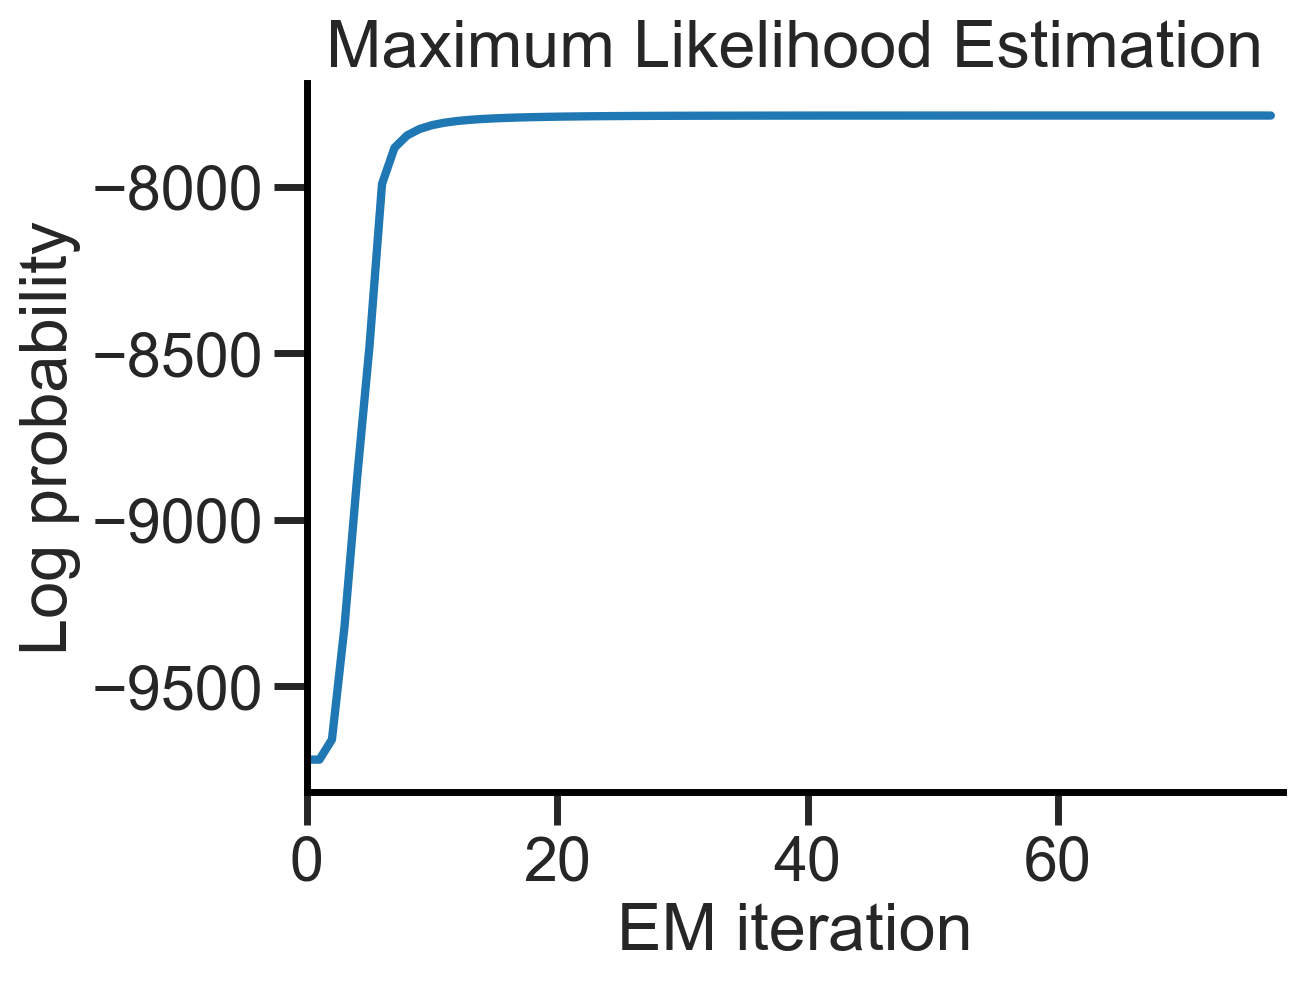

In [10]:
# Plot the log probabilities of the fit model
plt.figure(constrained_layout=True)
plt.plot(fit_ll)
plt.title('Maximum Likelihood Estimation')
plt.xlabel('EM iteration')
plt.xlim(0, len(fit_ll))
plt.ylabel('Log probability')
sns.despine()

### 3b. Retrieved parameters

In [11]:
weights = glmhmm.observations.params
weights = -weights  # Flip sign of weights
trans_mat = glmhmm.transitions.transition_matrix

In [12]:
# Interpret states and remap
state_labels, remap = interpret_states(weights)
weights = weights[remap]
state_labels = [state_labels[old] for old in remap]

State 1: engaged (stim. weight: 21.01, bias weight: -0.05)
State 0: left bias (stim. weight: 1.94, bias weight: -2.41)
State 2: right bias (stim. weight: 2.14, bias weight: 1.66)


Text(0.5, 1.0, 'Weights')

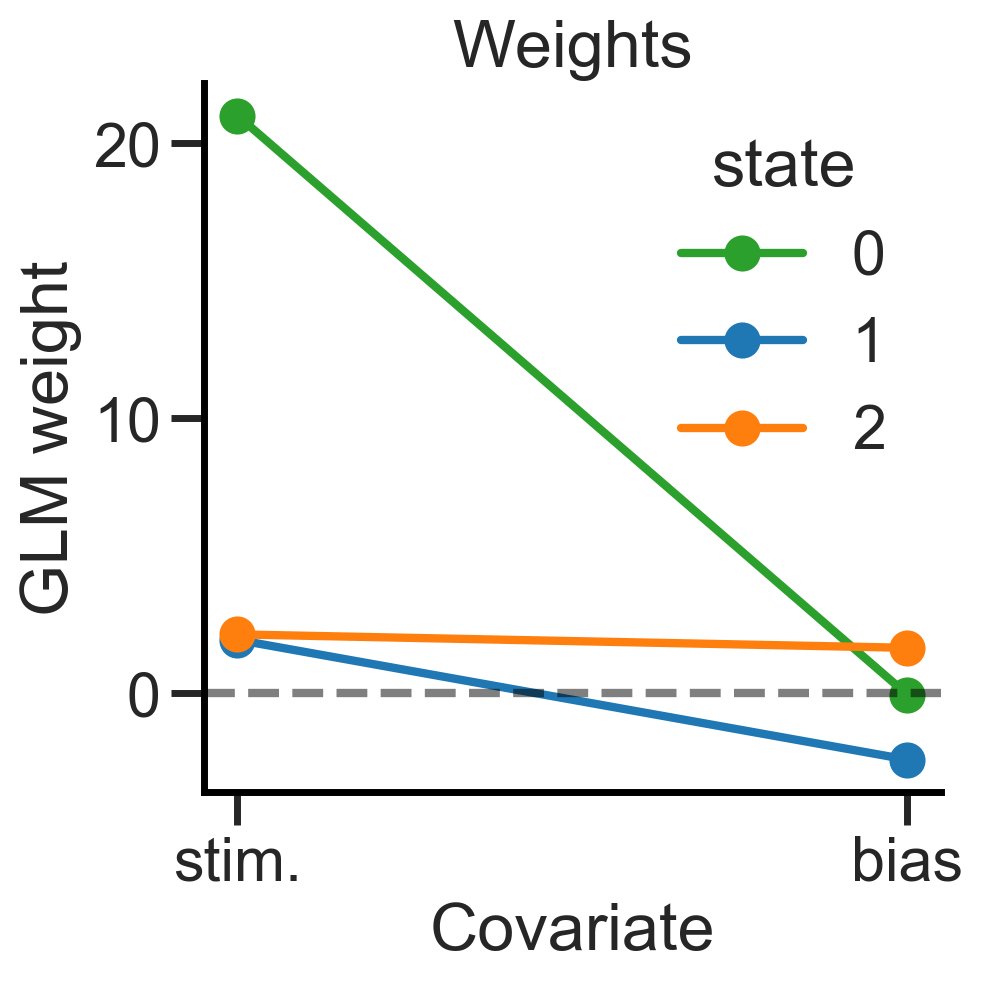

In [13]:
# Plot retrieved weights
plt.figure(figsize=(default_figsize[1], default_figsize[1]), constrained_layout=True)
colors = ['tab:green', 'tab:blue', 'tab:orange']
for k in range(n_states):
    plt.plot(range(input_dim), weights[k][0], marker='o', color=colors[k], linestyle='-', label=str(k + 0))
plt.yticks()
plt.ylabel('GLM weight')
plt.xlabel('Covariate')
plt.xticks(range(0, input_dim), ['stim.', 'bias'])
# plt.xticks(range(0, input_dim), ['stim.', 'bias', '$C_t$'])
plt.axhline(y=0, color='k', alpha=0.5, ls='--')
plt.legend(title='state')
plt.title('Weights')

Text(0.5, 1.0, 'Transition matrix')

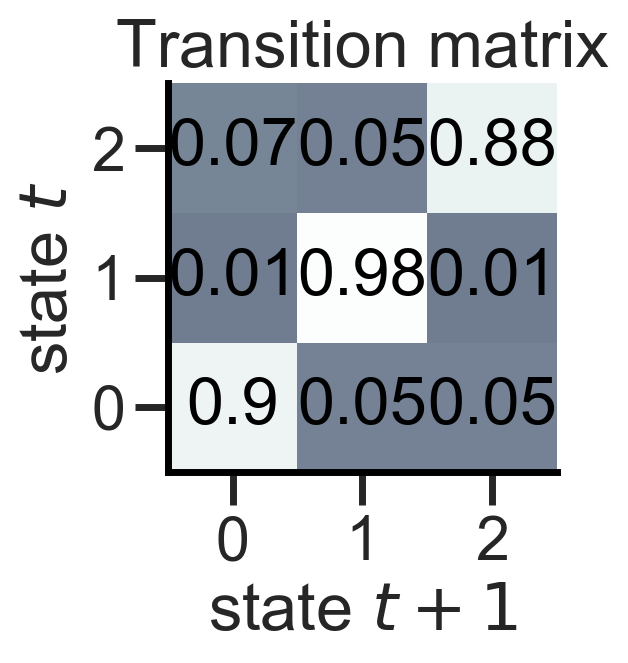

In [14]:
# Plot retrieved transition matrix
plt.figure(figsize=(default_figsize[0]/2, default_figsize[0]/2), constrained_layout=True)
# gen_trans_mat = np.exp(log_trans_mat)[0]
plt.imshow(trans_mat, vmin=-1, vmax=1, cmap='bone', origin='lower')

for i in range(trans_mat.shape[0]):
    for j in range(trans_mat.shape[1]):
        text = plt.text(j, i, str(np.around(trans_mat[i, j], decimals=2)), ha='center', va='center', color='k')

# plt.xlim(-0.5, n_states + 0.5)
ticks = range(0, n_states)
ticklabels = [str(i) for i in range(n_states)]
plt.xticks(ticks, ticklabels)
plt.yticks(ticks, ticklabels)
# plt.ylim(n_states - 0.5, -0.5)
plt.ylabel('state $t$')
plt.xlabel('state $t+1$')
plt.title('Transition matrix')

### 3c. Posterior State Probabilities

Let's now plot $p(z_{t} = k|\mathbf{y}, \{u_{t}\}_{t=1}^{T})$, the posterior state probabilities, which give the probability of the animal being in state k at trial t.

In [15]:
# Get expected states:
posterior_probs = [glmhmm.expected_states(data=data, input=input)[0]
                for data, input in zip(choices, inputs)]

In [16]:
# Remap posterior state probabilities
posterior_probs = [p[:, remap] for p in posterior_probs]

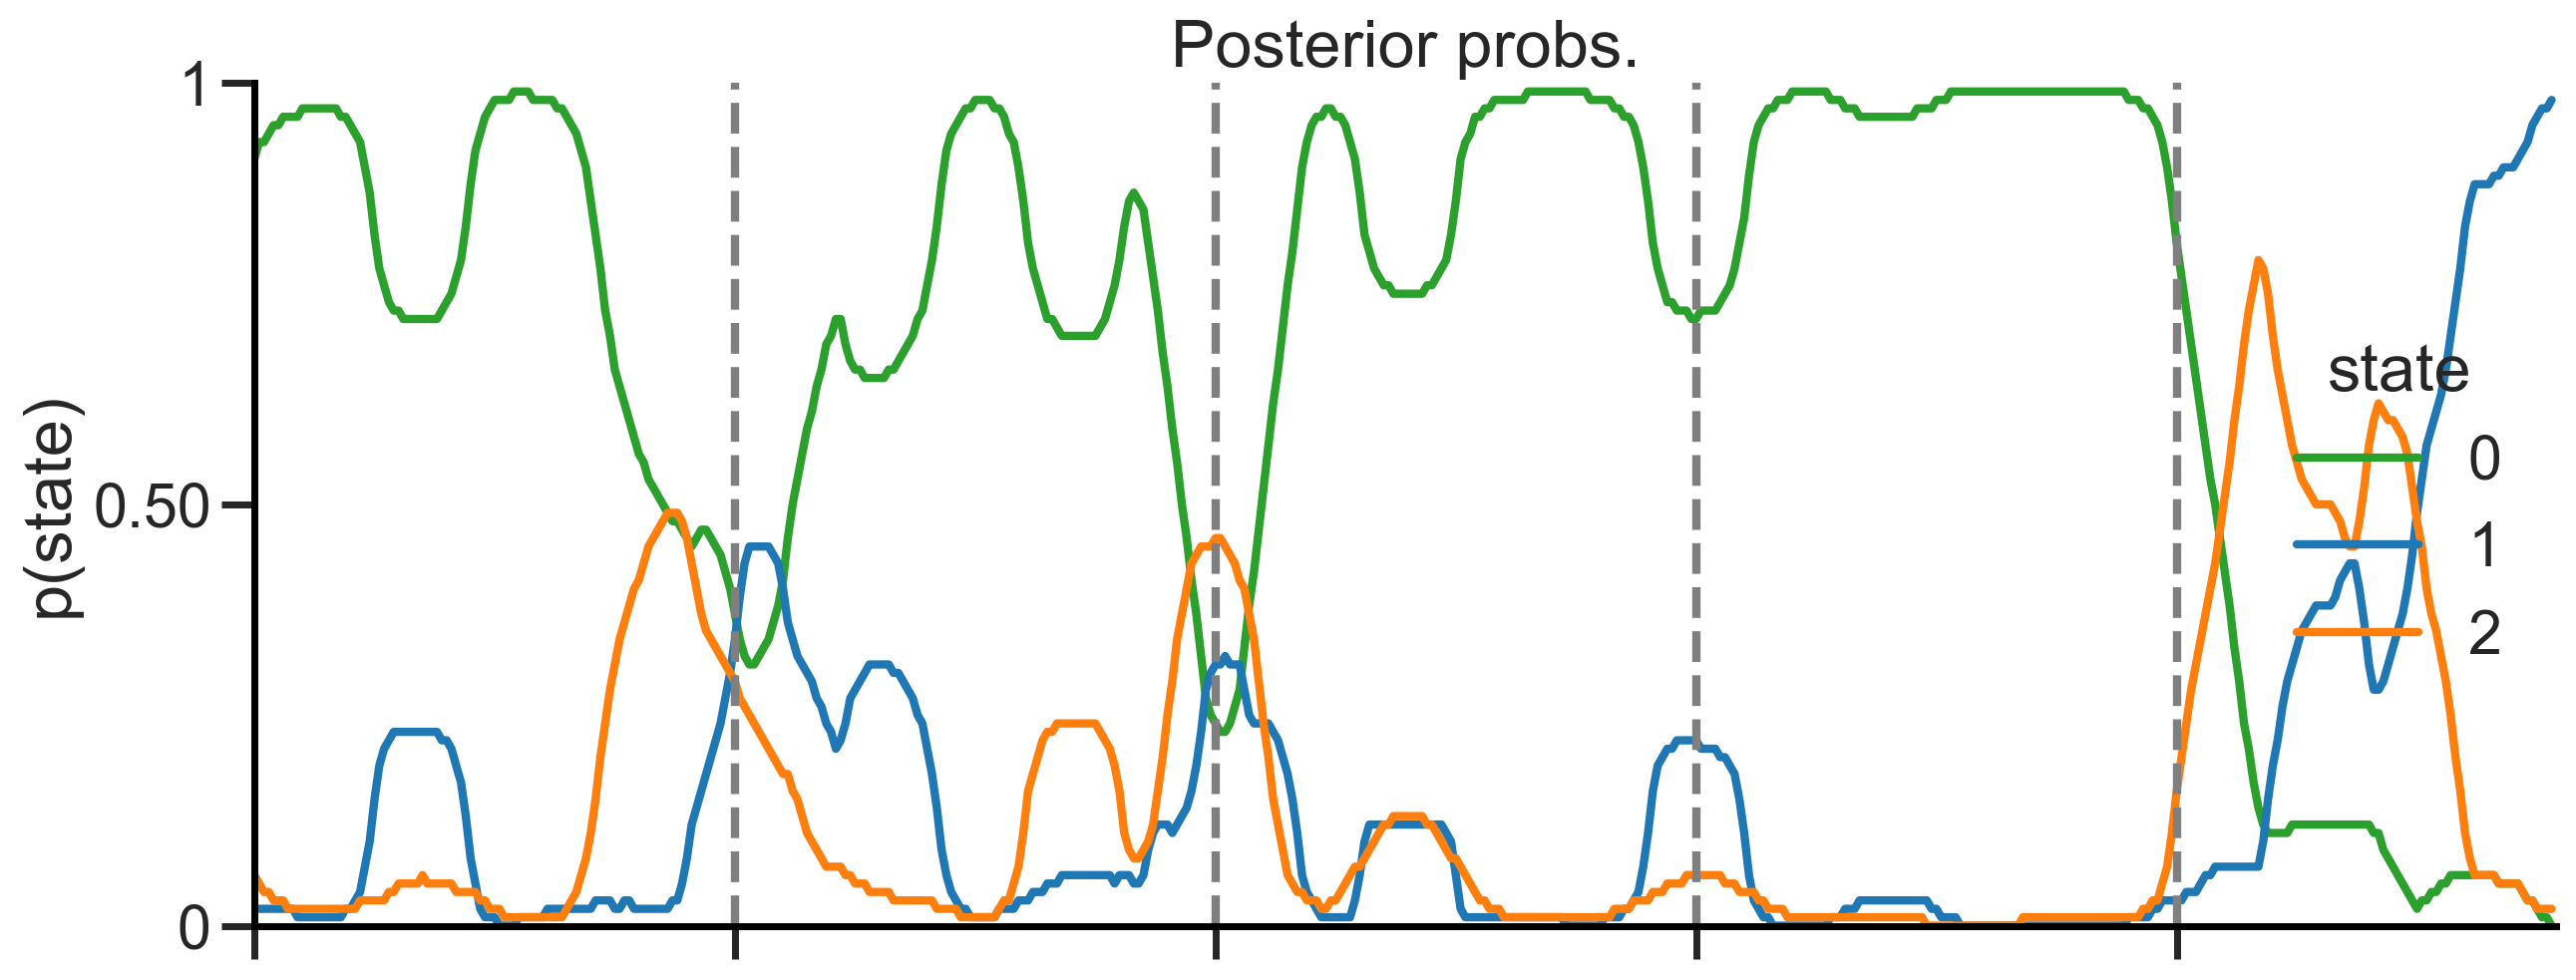

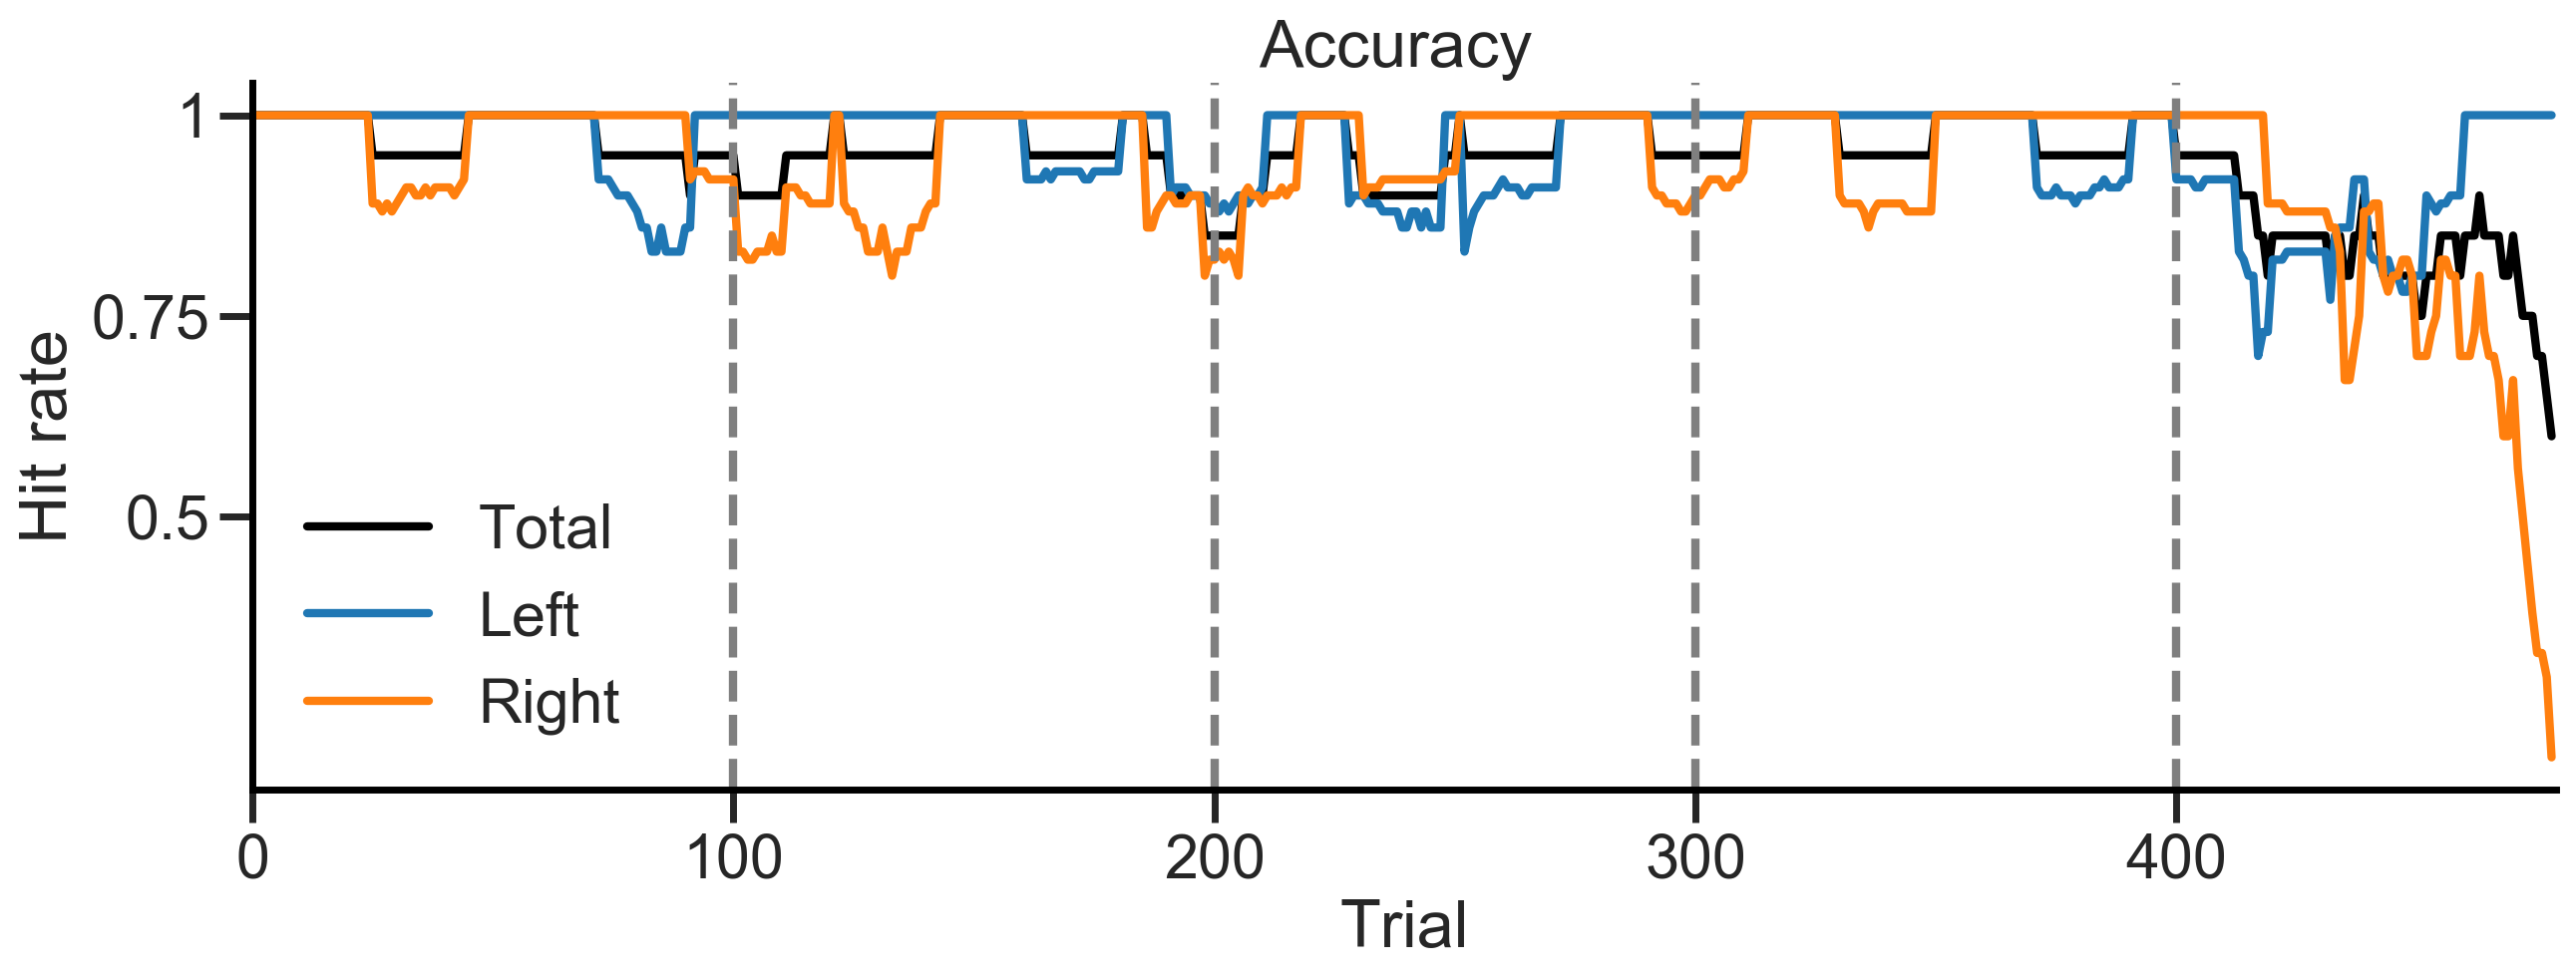

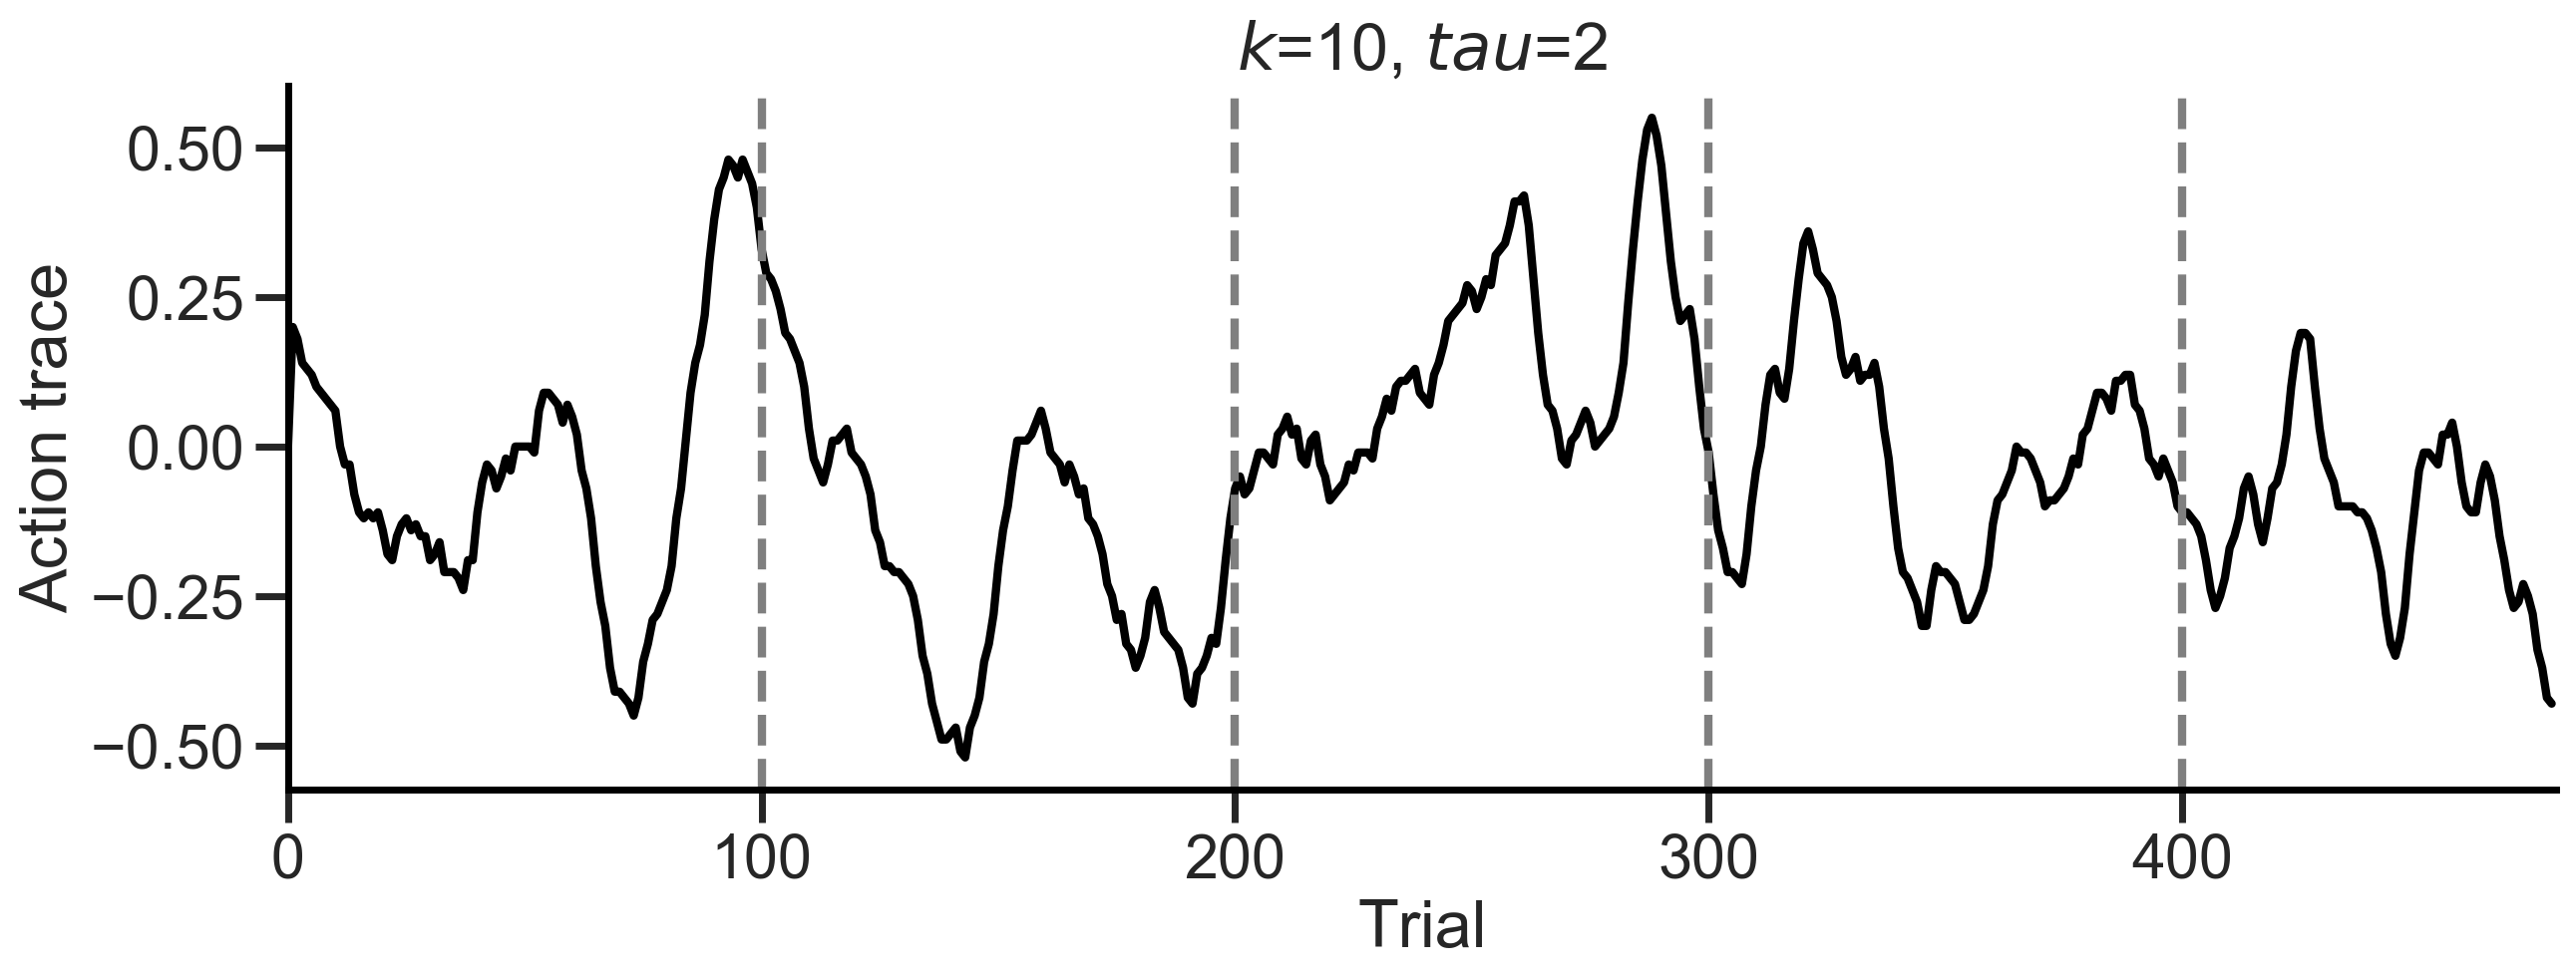

In [17]:
session_id = 0  # Can choose any index between 0 and n_sesssion

# Plot posterior state probabilities for one session
plt.figure(figsize=(default_figsize[0]*2, default_figsize[1]), constrained_layout=True)
probs = posterior_probs[session_id]
# plt.plot(compute_window(probs[:, 0]), color=colors[0], label=str(k + 0))
for k in range(n_states):
    # if k == 0:
        # plt.plot(posterior_probs[session_id][:, k], color=colors[k], label=str(k + 1))
        plt.plot(compute_window(probs[:, k]), color=colors[k], label=str(k + 0))
plt.title('Posterior probs.')
plt.xlim(0, len(probs))
plt.gca().set_xticklabels([])
plt.ylim(0, 1)
plt.yticks([0, 0.5, 1], ('0', '0.50', '1'))
# plt.xlabel('Trial')
plt.ylabel('p(state)')
plt.legend(title='state', loc='center right')
for x in range(100, len(probs), 100):
    plt.axvline(x, color='tab:gray', ls='--')


# Plot accuracy for the same session
df_session = df[df.SessionIndex==session_id].reset_index(drop=True)
indices = df_session.index
hits = df_session.Hit.values
# Mask left and right accuracies by filling non-matching trials with NaN
hits_left = np.where(df_session.Side==0, hits, np.nan)
hits_right = np.where(df_session.Side==1, hits, np.nan)
ra_total = compute_window(hits)
ra_left = compute_window(hits_left)
ra_right = compute_window(hits_right)
plt.figure(figsize=(default_figsize[0]*2, default_figsize[1]), constrained_layout=True)
plt.plot(indices, ra_total, color='k', label='Total')
plt.plot(indices, ra_left, color='tab:blue', label='Left')
plt.plot(indices, ra_right, color='tab:orange', label='Right')
plt.xlim(0, len(ra_total))
# plt.ylim((0.5, 1))
plt.xlabel('Trial')
plt.ylabel('Hit rate')
plt.yticks([0.5, 0.75, 1], ['0.5', '0.75', '1'])
plt.title('Accuracy ')
plt.legend()
for x in range(100, len(df_session), 100):
    plt.axvline(x, color='tab:gray', ls='--')


# Plot action trace
plt.figure(figsize=(default_figsize[0]*2, default_figsize[1]), constrained_layout=True)
action_trace = df[df.SessionIndex==session_id].ActionTrace.values
plt.plot(indices, compute_window(action_trace), color='k')
plt.xlim(0, len(action_trace))
plt.xlabel('Trial')
plt.ylabel('Action trace')
plt.title(f'$k$={max_trial_lag}, $tau$={tau}')
for x in range(100, len(probs), 100):
    plt.axvline(x, color='tab:gray', ls='--')

assert len(probs) == len(ra_total) == len(action_trace)

With these posterior state probabilities, we can assign trials to states and then plot the fractional occupancy of each state:

In [18]:
# Concatenate posterior probabilities across sessions
posterior_probs_concat = np.concatenate(posterior_probs)

# Get state with maximum posterior probability at particular trial
state_max_posterior = np.argmax(posterior_probs_concat, axis = 1)
df['State'] = state_max_posterior  # Add state column to df

# Obtain state fractional occupancies
_, state_occupancies = np.unique(state_max_posterior, return_counts=True)
state_occupancies = state_occupancies / np.sum(state_occupancies)

State 1 occupancy: 0.75
State 2 occupancy: 0.15
State 3 occupancy: 0.10


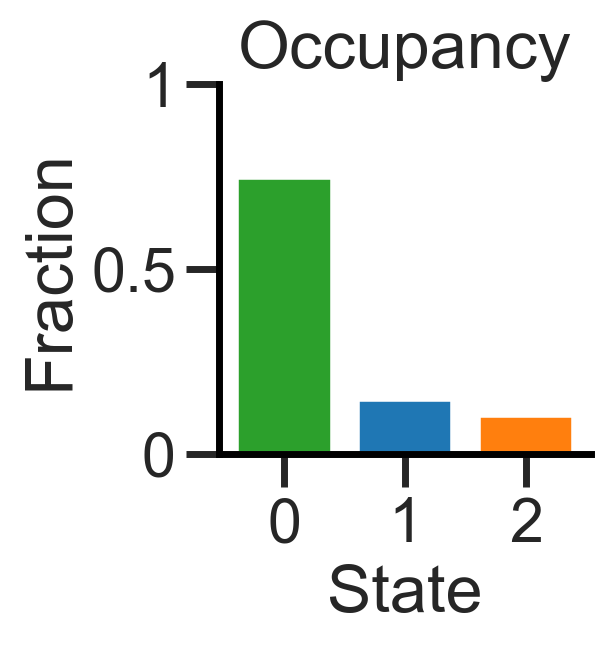

In [19]:
fig = plt.figure(figsize=(default_figsize[1]/2, default_figsize[1]/2))

for z, occ in enumerate(state_occupancies):
    print(f'State {z+1} occupancy: {occ:.2f}')
    plt.bar(z, occ, color = colors[z])

plt.ylim((0, 1))
plt.xticks(ticks, ticklabels)
plt.yticks([0, 0.5, 1], ['0', '0.5', '1'])
plt.xlabel('State')
plt.ylabel('Fraction')
plt.title('Occupancy')
sns.despine()

# Interpret states and remap

In [20]:
# # Interpret states
# state_labels, remap = interpret_states(weights)

In [21]:
# # Apply remap
# weights, posterior_probs, state_max_posterior, state_labels = apply_remap(remap, weights, posterior_probs, state_max_posterior, state_labels)

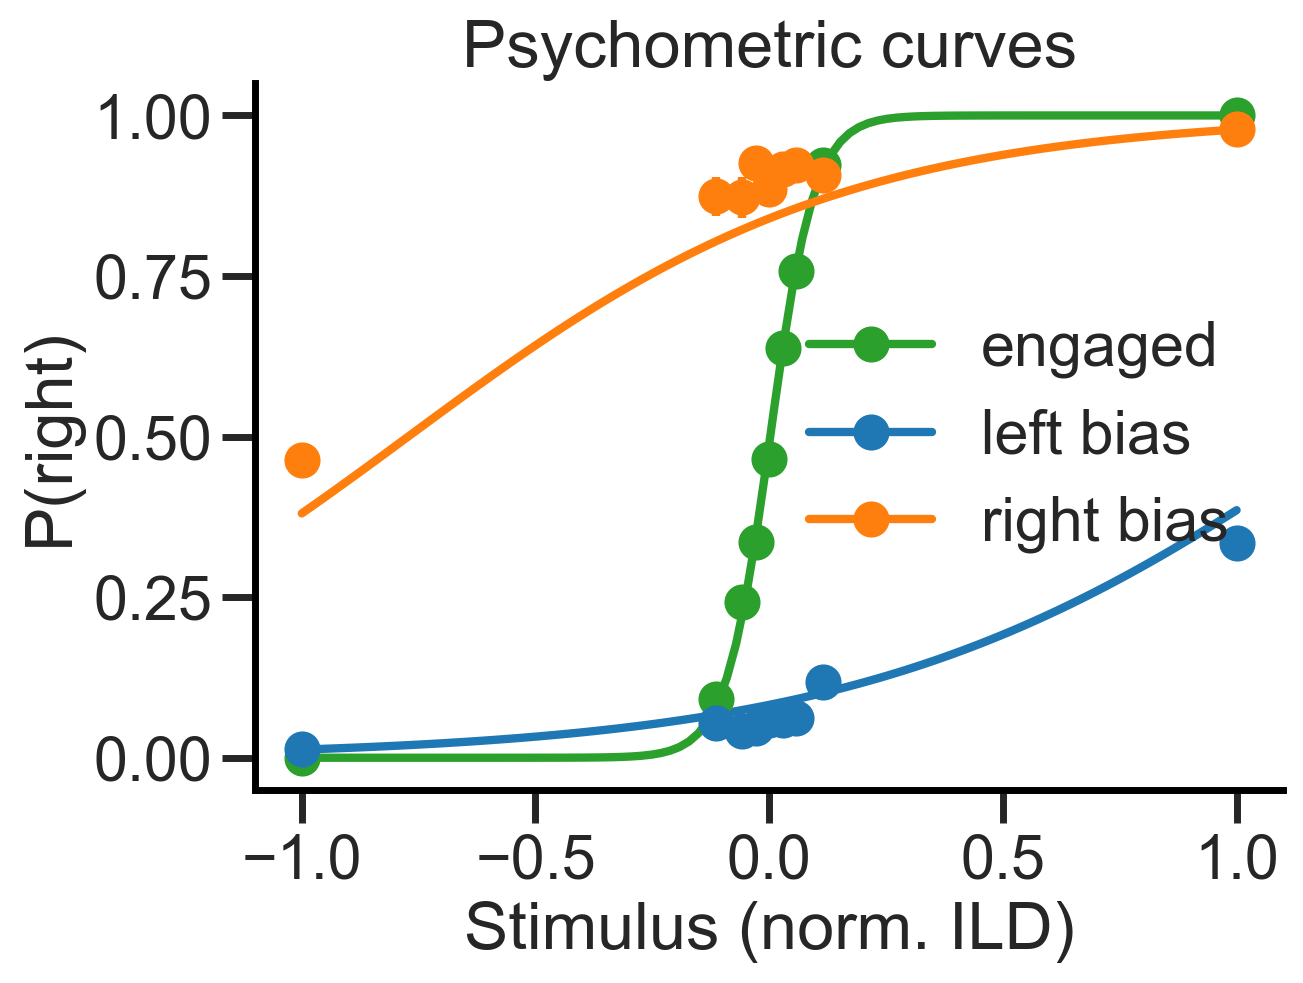

In [22]:
# Plot psychometric curves per state

stim_range = np.linspace(-1, 1, 100)  # Theory
x = sorted(df.ILD.unique())  # Data
x = x / abs(max(x))

plt.figure(constrained_layout=True)
for state in range(weights.shape[0]):
    w_stim = weights[state, 0, 0]
    w_bias = weights[state, 0, 1]
    probs = logistic(w_stim * stim_range + w_bias)
    plt.plot(stim_range, probs, color=colors[state])  # Theory
    y = df[df.State==state].groupby('ILD').Choice.mean()
    yerr = df[df.State==state].groupby('ILD').Choice.sem()
    plt.errorbar(x, y, yerr, marker='o', linestyle='None', color=colors[state])  # Data

# Create custom legend: line + dot together
legend_elements = [Line2D([0], [0], color=colors[state], marker='o', label=state_labels[state]) for state in range(weights.shape[0])]

plt.xlabel('Stimulus (norm. ILD)')
plt.ylabel('P(right)')
plt.title('Psychometric curves')
plt.legend(handles=legend_elements)

# Save all notebook's figures

In [23]:
# # Whole notebook ouputs (no input or prompt, only Markdown and figures)
# # As HTML
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt
# # As PDF
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt
#
# # Export all figures
# save_notebook_files('notebook.ipynb')